In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 3.1. Part A : Analyzing audio signal and downsampling
Objective: Observe an audio signal and learn how to downsample.
### (1) Switch to your virtual environment
### (2) Read the wav file “human_voice.wav” and write down its original sampling frequency.

In [16]:
orig_fs, data = wavfile.read("human_voice.wav")

print(f"Original sampling frequency: {orig_fs} Hz")
print(f"Original number of samples: {len(data)}")
print(f"Duration: {len(data)/orig_fs:.3f} seconds")

Original sampling frequency: 48000 Hz
Original number of samples: 85248
Duration: 1.776 seconds


Original sampling frequency: 48000 Hz

### (3) Plot the signal using matplotlib.

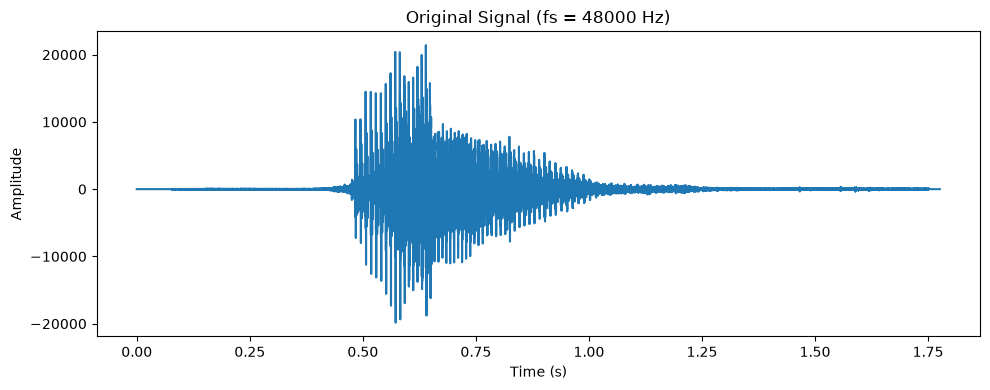

In [17]:
t_orig = np.arange(len(data)) / orig_fs

plt.figure(figsize=(10, 4))
plt.plot(t_orig, data)
plt.title(f"Original Signal (fs = {orig_fs} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("original_signal.png")
plt.show()

### (4) Downsample the audio file to 8kHz without using inbuilt functions.

In [18]:
target_fs = 8000

duration = len(data) / orig_fs
num_new_samples = int(duration * target_fs)

downsampled = np.zeros(num_new_samples, dtype=data.dtype)

for i in range(num_new_samples):
    # time of the i-th new sample
    t = i / target_fs
    # corresponding index in the ORIGINAL signal
    orig_index = int(round(t * orig_fs))
    # guard against rounding past the end of the array
    if orig_index >= len(data):
        orig_index = len(data) - 1
    downsampled[i] = data[orig_index]

### (5) How many audio samples were obtained after downsampling?

In [19]:
print(f"Number of samples after downsampling: {len(downsampled)}")

Number of samples after downsampling: 14208


Number of samples after downsampling: 14208

### (6) Plot the downsampled signal using matplotlib.

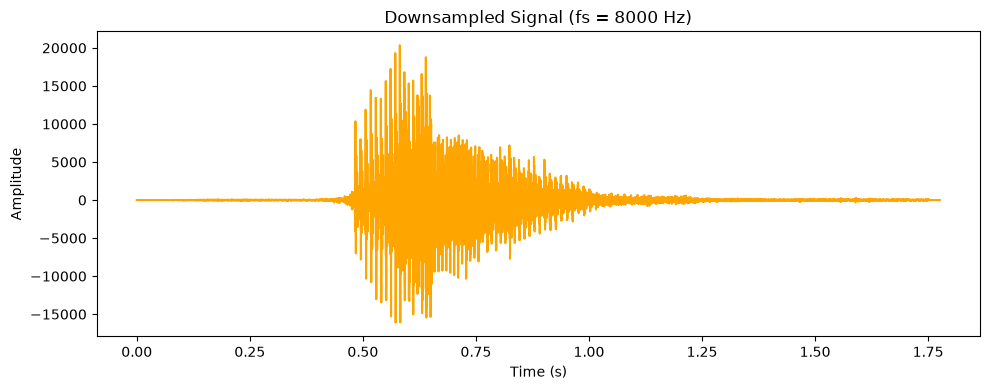

In [20]:
t_down = np.arange(len(downsampled)) / target_fs

plt.figure(figsize=(10, 4))
plt.plot(t_down, downsampled, color="orange")
plt.title(f"Downsampled Signal (fs = {target_fs} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("downsampled_signal.png")
plt.show()

### (7) Observe a section of the audio signal corresponding to the same time period (hint: think of the sampling ratio and select two starting and ending points). What differences do you notice?

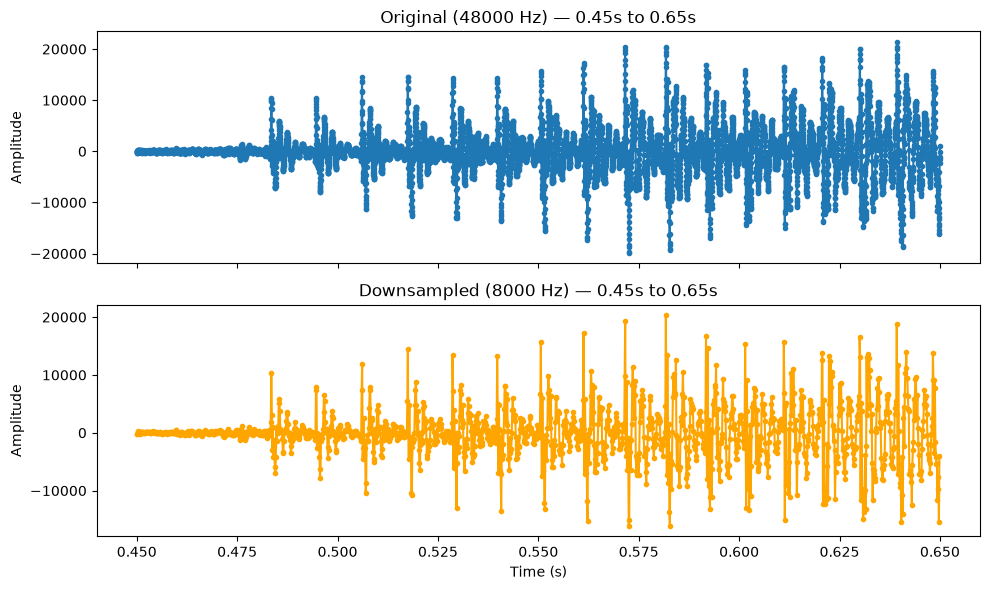

In [21]:
start_time, end_time = 0.45, 0.65

# indices for original signal
o_start = int(start_time * orig_fs)
o_end   = int(end_time * orig_fs)

# indices for downsampled signal
d_start = int(start_time * target_fs)
d_end   = int(end_time * target_fs)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(t_orig[o_start:o_end], data[o_start:o_end], marker='o', markersize=3)
axs[0].set_title(f"Original ({orig_fs} Hz) — {start_time}s to {end_time}s")
axs[0].set_ylabel("Amplitude")

axs[1].plot(t_down[d_start:d_end], downsampled[d_start:d_end],
            color="orange", marker='o', markersize=3)
axs[1].set_title(f"Downsampled (8000 Hz) — {start_time}s to {end_time}s")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig("comparison_zoom.png")
plt.show()

The first thing I notice is that the original audio is a lot finer detailed while the downsampled audio is coarser as there are less points sampled. A result of this is that some peaks or valleys are less intense (ie closer to 0) in the downsampled clip compared to the original since the maximum point isn't always the point that is sampled for a given peak since each peak is short compared to the sample frequency. Another thing I notice is that despite the previously mentioned loss the overall shape is still conserved. There are still peaks in the same places in the two samples and they share the same overall "silhouette". Overall there is reduced detail, but they still clearly appear to be the same audio sample and I would expect the overall sound to mostly be conserved based on the visual graphs. 

### (8) Show your work to the TA.
### (9) Upload your code to Github.

# 3.2. Part B: RMS, Cross-correlation, Sound Localization
Objective: Analyze the RMS value of an audio signal, find delay between audio signals received at two
locations, and determine the robot's orientation w.r.t. the sound source.
You are given three sound signals picked up from 3 microphones. Each of them are located at different
locations w.r.t the sound source. The microphones sample audio waves at 8 kHz.
### (1) Calculate the rms values for each of the audio signals M1.wav, M2.wav and M3.wav using Python. (Here M1.wav is the audio signal received by the microphone M1)

In [28]:
m1_fs, m1_data = wavfile.read("M1.wav")
m2_fs, m2_data = wavfile.read("M2.wav")
m3_fs, m3_data = wavfile.read("M3.wav")
m1_rms = np.sqrt(np.mean((m1_data.astype(np.float64))**2))
m2_rms = np.sqrt(np.mean((m2_data.astype(np.float64))**2))
m3_rms = np.sqrt(np.mean((m3_data.astype(np.float64))**2))
print(f"M1 RMS: {m1_rms}   |   M2 RMS: {m2_rms}   |   M3 RMS: {m3_rms}")

M1 RMS: 7383.243593119038   |   M2 RMS: 5906.3835785917545   |   M3 RMS: 7383.243593119038


### (2) Which microphone is the sound source closer to considering the rms value of M1 and M2?
Since the RMS is higher for M1 compared to M2 the sound source is closer to M1 as the closer sound means the total audio strenght the microphone picks up is larger, thus leading to the higehr RMS value.

### (3) Using the cross correlation equation given below, Calculate the time delay between 𝑅𝑥𝑦 M2 using Python. Try to compute this without the use of inbuilt functions.
Note: M1 and M2 are length of 24000

In [ ]:
m = np.zeros(24000)
for i in range(0,24000)
    for x in range(0,24000)

24000
24000



### (4) Given below is a rough sketch of a robot with two microphones M1 and M2. S is the sound source emitting the signal. d1 is the distance between the sound source and M1, and d2 is the distance between the sound source and M2. Calculate the angle θ which the robot must turn to correct its heading toward the sound source. Let r, the radius of the robot, be 10cm.
### (5) Show your work to the TA.
### (6) Upload your code to Github.
# 3.3. Part C: Frequency spectrum
### (1) Plot the audio signal “Cafe_with_noise.wav” using matplotlib.
### (2) Analyze the signal in the frequency domain to separate regions of human voice to noise.
### (3) Implement a low pass filter to remove the noise and obtain only the voice signal.
### (4) Show your work to the TA.
### (5) Upload your code to Github.